In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import classification_report, average_precision_score

In [11]:
# 1. Load Data
url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"
df = pd.read_csv(url)
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded with 284807 rows and 31 columns.


In [ ]:
# 2. Preprocessing
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df = df.drop(['Time'], axis=1) 
X = df.drop('Class', axis=1)
y = df['Class']

# 3. Train/Test Split (Stratified to maintain fraud ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Handle Imbalance with SMOTE
# We only oversample the TRAINING data to avoid data leakage
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# 5. Model Training (Random Forest or XGBoost)
model = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
model.fit(X_train_res, y_train_res)

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio, # This is the magic parameter for fraud
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)

# Fit the model
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Results
print("--- XGBoost Results ---")
print(classification_report(y_test, y_pred_xgb))
print(f"XGBoost AUPRC: {average_precision_score(y_test, y_probs_xgb):.4f}")



In [ ]:
# 6. Evaluation
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"Area Under PR Curve: {average_precision_score(y_test, y_probs):.4f}")

Dataset loaded: 284807 rows, 31 columns

--- Running Random Forest + SMOTE ---
--- Running XGBoost + scale_pos_weight ---

Random Forest AUPRC: 0.8293
XGBoost AUPRC:       0.8779


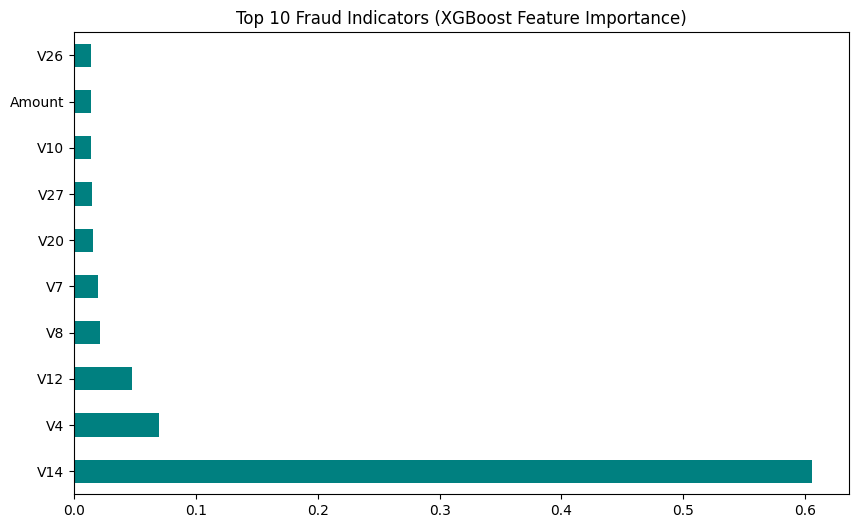

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, average_precision_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb

# 1. LOAD DATA (Online access)
url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"
df = pd.read_csv(url)
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# 2. PREPROCESSING
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df = df.drop(['Time'], axis=1) 

X = df.drop('Class', axis=1)
y = df['Class']

# 3. STRATIFIED SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. METHOD A: Random Forest with SMOTE (Oversampling)
print("\n--- Running Random Forest + SMOTE ---")
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
rf_model.fit(X_train_res, y_train_res)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# 5. METHOD B: XGBoost with Cost-Sensitive Weighting
print("--- Running XGBoost + scale_pos_weight ---")
# Calculate weight ratio to handle imbalance without creating synthetic data
ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# 6. COMPARATIVE EVALUATION
print("\n" + "="*30)
print(f"Random Forest AUPRC: {average_precision_score(y_test, rf_probs):.4f}")
print(f"XGBoost AUPRC:       {average_precision_score(y_test, xgb_probs):.4f}")
print("="*30)

# 7. FEATURE IMPORTANCE VISUALIZATION
plt.figure(figsize=(10,6))
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Fraud Indicators (XGBoost Feature Importance)')
plt.show()

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_val_score(xgb_model, X, y, cv=skf, scoring='average_precision')

print(f"CV AUPRC: {cv_results.mean():.4f} (+/- {cv_results.std():.4f})")

CV AUPRC: 0.8616 (+/- 0.0260)


In [18]:
from sklearn.metrics import confusion_matrix

# Define hypothetical costs
cost_fn = 100  # Cost of missing a fraud
cost_fp = 10   # Cost of a false alarm (e.g., customer service call)

best_threshold = 0.5
min_cost = float('inf')

for t in np.arange(0.1, 0.9, 0.001):
    y_pred_t = (xgb_probs > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    total_cost = (fn * cost_fn) + (fp * cost_fp)
    
    if total_cost < min_cost:
        min_cost = total_cost
        best_threshold = t

print(f"Business-Optimal Threshold: {best_threshold:.2f} at Cost: ${min_cost}")

Business-Optimal Threshold: 0.26 at Cost: $1510


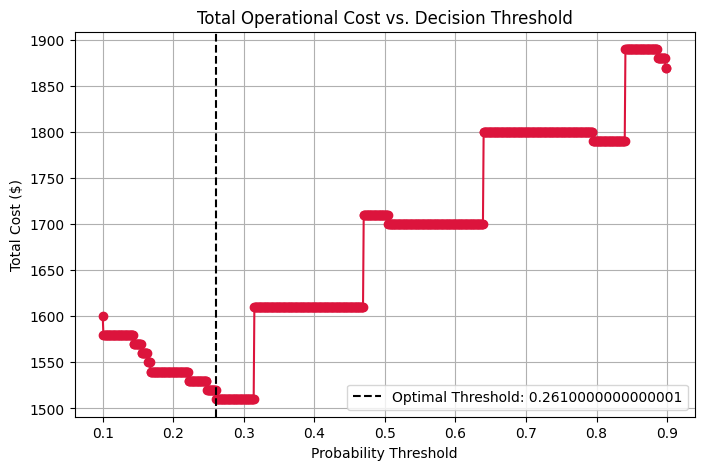

In [19]:
costs = []
thresholds = np.arange(0.1, 0.9, 0.001)

for t in thresholds:
    y_pred_t = (xgb_probs > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    costs.append((fn * cost_fn) + (fp * cost_fp))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, costs, marker='o', color='crimson')
plt.axvline(best_threshold, color='black', linestyle='--', label=f'Optimal Threshold: {best_threshold}')
plt.title('Total Operational Cost vs. Decision Threshold')
plt.xlabel('Probability Threshold')
plt.ylabel('Total Cost ($)')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
from sklearn.ensemble import IsolationForest

# Contamination is the expected percentage of fraud (0.17%)
iso_forest = IsolationForest(n_estimators=100, contamination=0.0017, random_state=42)

# Fit on training data (standard practice is to fit only on 'Normal' cases)
iso_forest.fit(X_train)

# Predict: -1 for anomaly, 1 for normal
iso_preds = iso_forest.predict(X_test)
iso_preds = np.where(iso_preds == -1, 1, 0) # Convert to 0/1 for evaluation

print("--- Isolation Forest Results ---")
print(classification_report(y_test, iso_preds))

--- Isolation Forest Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.32      0.33      0.32        98

    accuracy                           1.00     56962
   macro avg       0.66      0.66      0.66     56962
weighted avg       1.00      1.00      1.00     56962



Epoch 1/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 2s 324us/step - loss: 0.4966 - val_loss: 0.4041
Epoch 2/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 2s 311us/step - loss: 0.3832 - val_loss: 0.3680
Epoch 3/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 2s 329us/step - loss: 0.3608 - val_loss: 0.3629
Epoch 4/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 2s 313us/step - loss: 0.3410 - val_loss: 0.3218
Epoch 5/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 2s 301us/step - loss: 0.3141 - val_loss: 0.3068
Epoch 6/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 2s 331us/step - loss: 0.3035 - val_loss: 0.3001
Epoch 7/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 2s 304us/step - loss: 0.3026 - val_loss: 0.2990
Epoch 8/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 2s 298us/step - loss: 0.2992 - val_loss: 0.2969
Epoch 9/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 2s 300us/step - loss: 0.2980 - val_loss: 0.2952
Epoch 10/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 2s 298us/step - loss: 0.2964 - val_loss: 0.2935
Epoch 11/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 2s 305us/step - loss: 0.2950 - val_loss: 0.2919
Epoch 12

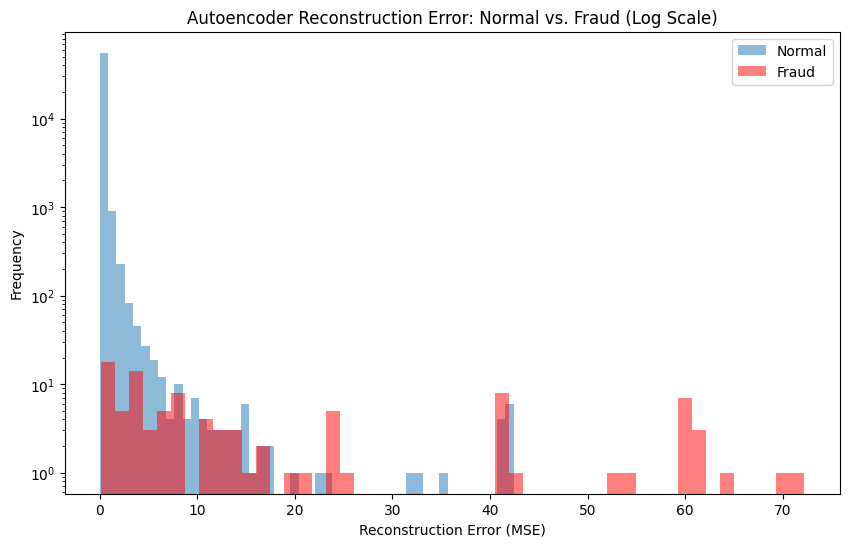

In [26]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# 1. Filter for 'Normal' transactions only for training
X_train_normal = X_train[y_train == 0]

# 2. Define Architecture (Bottleneck design)
input_dim = X_train.shape[1]
encoding_dim = 14 

input_layer = Input(shape=(input_dim,))
encoder = Dense(encoding_dim, activation="relu")(input_layer)
# Added a hidden layer for better feature extraction
hidden = Dense(int(encoding_dim/2), activation="relu")(encoder)
decoder_hidden = Dense(encoding_dim, activation="relu")(hidden)
decoder = Dense(input_dim, activation="linear")(decoder_hidden) # Linear for reconstruction

autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mse')

# 3. Train only on Normal data
# Increased epochs to 20 for stability (100 might overfit if validation loss stops dropping)
history = autoencoder.fit(
    X_train_normal, X_train_normal, 
    epochs=20, 
    batch_size=32, 
    validation_split=0.2,
    verbose=1
)

# 4. Detect Fraud via Reconstruction Error (MSE)
predictions = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - predictions, 2), axis=1)

# 5. Evaluation & Comparison
error_df = pd.DataFrame({'reconstruction_error': mse, 'true_class': y_test})

print("\n" + "="*30)
print("MEAN RECONSTRUCTION ERROR BY CLASS:")
print(error_df.groupby('true_class')['reconstruction_error'].mean())
print("="*30)

# Calculate Autoencoder AUPRC
ae_auprc = average_precision_score(y_test, mse)
print(f"Autoencoder AUPRC: {ae_auprc:.4f}")

# 6. Visualization: The "Anomaly Gap"
plt.figure(figsize=(10,6))
plt.hist(error_df[error_df['true_class']==0]['reconstruction_error'], bins=50, alpha=0.5, label='Normal', log=True)
plt.hist(error_df[error_df['true_class']==1]['reconstruction_error'], bins=50, alpha=0.5, label='Fraud', log=True, color='red')
plt.title('Autoencoder Reconstruction Error: Normal vs. Fraud (Log Scale)')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

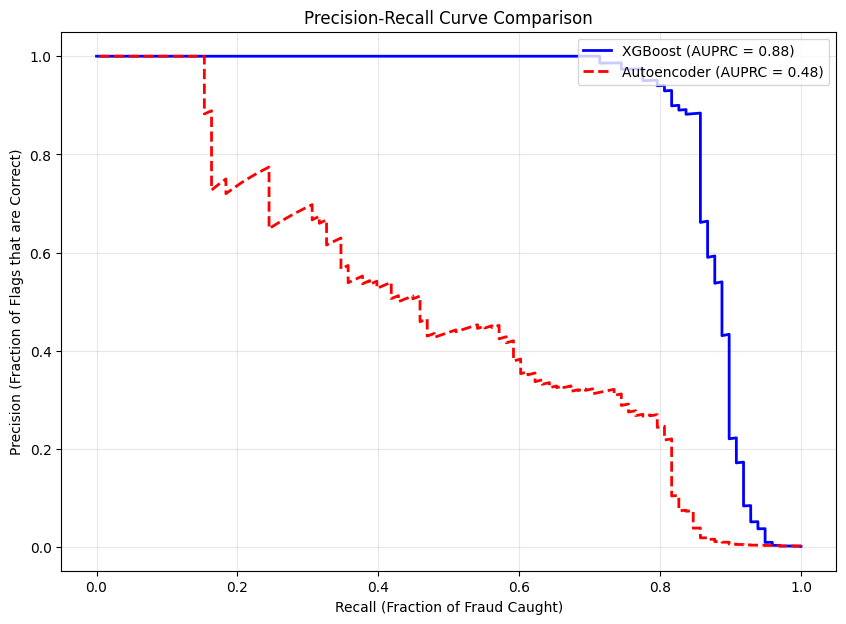

In [27]:
from sklearn.metrics import precision_recall_curve, auc

# Calculate PR Curve data for XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, xgb_probs)
auc_xgb = auc(recall_xgb, precision_xgb)

# Calculate PR Curve data for Autoencoder (using MSE as the score)
precision_ae, recall_ae, _ = precision_recall_curve(y_test, mse)
auc_ae = auc(recall_ae, precision_ae)

# Plotting
plt.figure(figsize=(10, 7))
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AUPRC = {auc_xgb:.2f})', color='blue', lw=2)
plt.plot(recall_ae, precision_ae, label=f'Autoencoder (AUPRC = {auc_ae:.2f})', color='red', linestyle='--', lw=2)

plt.xlabel('Recall (Fraction of Fraud Caught)')
plt.ylabel('Precision (Fraction of Flags that are Correct)')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()